In [ ]:
!pip install mujoco gymnasium[mujoco] ray==2.55.1 ray[rllib,tune]==2.55.1 mediapy

zsh:1: no matches found: gymnasium[mujoco]


# Imports and Functions

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
from torch.distributions.normal import Normal
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
from collections import deque
import mediapy as media
# Change to glfw when on Mac. This might fuck up the lighting.
%env MUJOCO_GL=egl
# import warnings
import ray
from ray.rllib.algorithms.ppo import PPO, PPOConfig
from ray.rllib.algorithms.sac import SAC, SACConfig
from ray import tune, air
import logging
ray.init(ignore_reinit_error=True, logging_level=logging.ERROR)


env: MUJOCO_GL=egl


E0000 00:00:1781624598.032969 1496012 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781624598.036098 1496012 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/home/johannes/anaconda3/envs/ml4robotics/lib/python3.11/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.11.9
Ray version:,2.55.1


In [ ]:
def render_episode(policy, env_name, env_options={}):
    env = gym.make(env_name,render_mode='rgb_array',**env_options)
    frames = []
    score = 0
    state = env.reset()[0]
    terminated = truncated = False
    while not terminated and not truncated:
        frame = env.render()
        frames.append(frame)
        action = policy(state)
        state, reward, terminated, truncated, _ = env.step(action)
        score += reward
    env.close()
    print(f"Finished episode. Cummulative Return: {score}")
    media.show_video(frames, fps=30, loop=True)

# Policy Gradients: The REINFORCE algorithm
Policy gradients serve as a cornerstone in reinforcement learning, offering a direct approach to learning optimal policies in uncertain environments. Unlike value-based methods that estimate the value function and derive policies from it, policy gradients directly optimize the policy's parameters. This direct optimization facilitates learning in environments with high-dimensional or continuous action spaces, where traditional methods might struggle. By iteratively adjusting the policy parameters to maximize expected rewards, policy gradients enable agents to learn complex behaviors and strategies over time, offering flexibility and adaptability.

Within the realm of policy gradients, the REINFORCE algorithm stands out as a prominent technique. As a policy gradient algorithm, REINFORCE operates by sampling trajectories, computing their returns, and adjusting the policy parameters based on these returns. It encourages actions that lead to higher rewards by updating the policy in the direction of the gradient of expected rewards. REINFORCE estimates the policy gradients, using Monte-Carlo samples, as:

$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \sum_t \nabla_\theta \log \pi_\theta (a_t | s_t) \cdot G_t \right]$

Despite its simplicity, REINFORCE has demonstrated effectiveness in various domains, from game playing to robotics, showcasing its versatility and applicability in real-world scenarios. However, it's important to note that while REINFORCE is a straightforward and intuitive method, more advanced algorithms such as Trust Region Policy Optimization (TRPO) and Proximal Policy Optimization (PPO) have been developed to address its limitations and improve sample efficiency and stability in training. These advancements highlight the ongoing evolution and refinement of policy gradient methods in reinforcement learning research and practice.

In [ ]:
class Policy_Network(nn.Module):
    def __init__(self, obs_space_dims: int, action_space_dims: int, hidden_space:int=32):
        super().__init__()

        # Shared Network
        self.shared_net = nn.Sequential(
            nn.Linear(obs_space_dims, hidden_space),
            nn.ReLU(),
            nn.Linear(hidden_space, hidden_space),
            nn.ReLU(),
        )

        # Policy Mean specific Linear Layer
        self.policy_mean_net = nn.Sequential(
            nn.Linear(hidden_space, action_space_dims)
        )

        # Policy Std Dev specific Linear Layer
        self.policy_stddev_net = nn.Sequential(
            nn.Linear(hidden_space, action_space_dims)
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        shared_features = self.shared_net(x.float())

        action_means = self.policy_mean_net(shared_features)

        # convert to positive: softplus(x) = log(1 + exp(x))
        action_stddevs = torch.log(
            1 + torch.exp(self.policy_stddev_net(shared_features))
        )

        return action_means, action_stddevs

In [ ]:
class ReinforceAgent:
    def __init__(self, obs_space_dims: int, action_space_dims: int):

        # Hyperparameters
        self.learning_rate = 1e-3
        self.gamma = 0.99
        self.eps = 1e-6

        self.probs = []  # Stores (log) probability values of the sampled action
        self.rewards = []  # Stores the corresponding rewards

        self.net = Policy_Network(obs_space_dims, action_space_dims)
        self.optimizer = torch.optim.Adam(self.net.parameters(), lr=self.learning_rate)

    def act(self, state: np.ndarray) -> float:
        state = torch.tensor(np.array([state]))
        action_means, action_stddevs = self.net(state)

        # create a normal distribution from the predicted
        # mean and standard deviation and sample an action
        distrib = Normal(action_means[0] + self.eps, action_stddevs[0] + self.eps)
        action = distrib.sample()
        prob = distrib.log_prob(action)  # used for update
        action = action.numpy()
        self.probs.append(prob)
        return action

    def learn(self):
        running_g = 0
        gs = []

        for R in self.rewards[::-1]:
            running_g = R + self.gamma * running_g
            gs.insert(0, running_g)

        deltas = torch.tensor(gs)

        loss = 0

        # minimize -1 * prob * reward obtained
        for log_prob, delta in zip(self.probs, deltas):
            loss += log_prob.mean() * delta * (-1)

        # Update the policy network
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Empty / zero out all episode-centric/related variables
        self.probs = []
        self.rewards = []

In [ ]:
# environment
env_name = "Hopper-v4"
env_options = {}
env = gym.make(env_name,**env_options)
solved = 500

total_num_episodes = int(10000)  # Total number of episodes
obs_space_dims = env.observation_space.shape[0]
action_space_dims = env.action_space.shape[0]


agent = ReinforceAgent(obs_space_dims, action_space_dims)
# Lists to keep track of training statistics.
scores = []
scores_window = deque(maxlen=1000)

for episode in range(total_num_episodes):
	obs, info = env.reset()
	score = 0.
	done = False
	while not done:
		action = agent.act(obs)
		obs, reward, terminated, truncated, info = env.step(action)
		agent.rewards.append(reward)
		score += reward
		done = terminated or truncated
	agent.learn()
	## metrics for plotting and reporting
	scores.append(score)
	scores_window.append(score)
	print(f'\rEpisode {episode}\tAverage Score: {np.mean(scores_window):.1f}', end="")
	if episode % 1000 == 0:
		print(f'\rEpisode {episode}\tAverage Score: {np.mean(scores_window):.1f}')
	if np.mean(scores_window)>=solved:
		print(f'\rEnvironment solved. Episode {episode}\tAverage Score: {np.mean(scores_window):.1f}')
		break

/home/johannes/anaconda3/envs/ml4robotics/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Episode 0	Average Score: 7.8
Episode 1000	Average Score: 170.9
Episode 2000	Average Score: 286.7
Episode 3000	Average Score: 5.302
Episode 4000	Average Score: 5.3
Episode 5000	Average Score: 5.7
Episode 6000	Average Score: 6.2
Episode 7000	Average Score: 7.9
Episode 8000	Average Score: 105.8
Episode 9000	Average Score: 373.8
Episode 9999	Average Score: 14.97

Text(0, 0.5, 'cum. return (smoothed)')

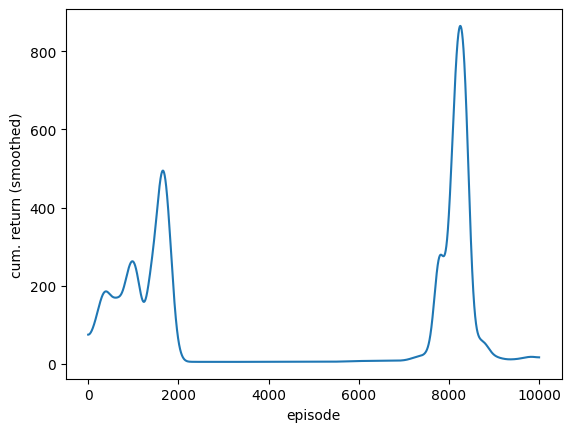

In [ ]:
# plotting
fig, ax = plt.subplots()
ax.plot(gaussian_filter(scores, 100))
ax.set_xlabel('episode')
ax.set_ylabel('cum. return (smoothed)')

In [ ]:
# Render an episode
render_episode(agent.act, env_name, env_options)

/home/johannes/anaconda3/envs/ml4robotics/lib/python3.11/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Finished episode. Cummulative Return: 12.483676830101388


This browser does not support the video tag.


### Tasks
1. Compare exploration strategies of REINFORCE against the epsilon-greedy exploration from q-learning.
2. Compare stability of convergence and sample efficiency of REINFORCE against DQN.
3. (Homework) Actor-Critic (AC) is a fundamental reinforcement learning algorithm that combines aspects of both policy-based and value-based methods. Unlike REINFORCE, which is purely a policy gradient method, AC maintains two separate networks: an actor network responsible for selecting actions based on the current state and a critic network that evaluates the chosen actions by estimating their value. This dual-network architecture allows AC to learn both the policy and the value function simultaneously. While REINFORCE updates the policy solely based on the total return obtained from each episode, Actor-Critic uses the critic's value estimates to calculate advantages, which represent the discrepancy between the estimated value of an action and the expected value
$A(s_t,a_t) = r_{t+1} + \gamma \cdot V(s_{t+1}) - V(s_t)$.
By incorporating this advantage information, Actor-Critic typically converges faster and exhibits lower variance compared to REINFORCE, making it more efficient and stable for learning in complex environments. Implement AC.

## Advanced Policy Gradients
Following the basic policy gradient methods, many improvements such as trust regions or natural gradients have been proposed. Today, a standard policy gradient method that is widely used is [PPO](https://arxiv.org/abs/1707.06347). A widely used actor-critic method is [SAC](https://arxiv.org/abs/1801.01290).

Proximal Policy Optimization (PPO) represents a significant advancement in reinforcement learning algorithms, particularly within the domain of policy gradients. Designed to address several challenges encountered in earlier methods such as REINFORCE, PPO focuses on improving both sample efficiency and policy stability during training. One of its key innovations lies in the use of a clipped surrogate objective function, which constrains policy updates to prevent significant deviations from the previous policy. By limiting the magnitude of policy changes, PPO ensures smoother learning trajectories and more stable training dynamics, ultimately leading to faster convergence and improved performance. Moreover, PPO's simplicity and effectiveness have contributed to its widespread adoption across various research and practical applications in fields ranging from robotics and game playing to natural language processing. Its robustness and versatility make PPO a go-to choice for many reinforcement learning tasks, highlighting its significance in advancing the capabilities of autonomous agents in complex environments.

Soft Actor-Critic (SAC) is an advanced reinforcement learning algorithm that blends the strengths of both policy-based and value-based methods. SAC belongs to the class of actor-critic algorithms, where it simultaneously learns a policy (actor) and a value function (critic). What sets SAC apart is its incorporation of a maximum entropy framework, which promotes robust exploration in the learning process. By maximizing the entropy of the policy, SAC encourages stochasticity in actions, leading to more diverse exploration strategies and ultimately better sample efficiency. Furthermore, SAC utilizes two critics to mitigate the overestimation bias often encountered in value-based methods. This combination of features makes SAC particularly effective for complex, high-dimensional continuous action spaces, where exploration is crucial for discovering optimal policies. Overall, SAC stands as a powerful algorithm in the field of reinforcement learning, known for its ability to handle challenging environments with continuous action spaces while achieving high performance and sample efficiency.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir ~/ray_results

In [ ]:
### Solution
# Stopper class to stop training when the episode return mean is above a threshold
class StopOnSuccess(ray.tune.Stopper):
    def __init__(self, metric: str, threshold: float):
        self.metric = metric
        self.threshold = threshold
        self._stop_all = False

    def __call__(self, trial_id: str, result: dict) -> bool:
        value = ray.tune.utils.unflattened_lookup(self.metric, result, default=None)
        if value is not None and value >= self.threshold:
            self._stop_all = True
        return self._stop_all

    def stop_all(self) -> bool:
        return self._stop_all

# Instantiate the PPO config
config = PPOConfig()

# Configure the training parameters
config = config.training(
    lr=tune.loguniform(1e-5, 1e-2),
    gamma=0.99,
)

# Configure the framework, workers, and environment
config = config.framework("torch")
config = config.env_runners(num_env_runners=1)  # separate workers to collect experience
config = config.environment("Hopper-v4")

# Run the training process
result = tune.Tuner(
    "PPO",
    run_config=air.RunConfig(
        stop=StopOnSuccess("env_runners/episode_return_mean", 2000),
        checkpoint_config=air.CheckpointConfig(
            checkpoint_frequency=1,
            checkpoint_at_end=True,
            num_to_keep=1,
            checkpoint_score_attribute="env_runners/episode_return_mean",
            checkpoint_score_order="max",
        ),
    ),
    tune_config=tune.TuneConfig(
        metric="env_runners/episode_return_mean",
        mode="max",
        num_samples=10,
    ),
    param_space=config,
).fit()


2026-06-16 17:51:16,174	WARNING algorithm_config.py:5108 -- You are running PPO on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(pid=1502654) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=1502654) E0000 00:00:1781625076.972913 1502654 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=1502654) E0000 00:00:1781625076.976266 1502654 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(PPO pid=1502654) 2026-06-16 17:51:20,053	WARNING algorithm_config.py:5108 -- You are running PPO on the 

In [ ]:
# Render the best result
best_result = result.get_best_result(metric="env_runners/episode_return_mean", mode="max")
best_algo = PPO.from_checkpoint(best_result.checkpoint.path)
rl_module = best_algo.get_module()
action_dist_cls = rl_module.get_inference_action_dist_cls()

def hopper_policy(obs):
    obs_batch = torch.from_numpy(np.asarray(obs, dtype=np.float32)).unsqueeze(0)
    dist_inputs = rl_module.forward_inference({"obs": obs_batch})["action_dist_inputs"]
    dist = action_dist_cls.from_logits(dist_inputs).to_deterministic()
    return dist.sample()[0].numpy()

render_episode(hopper_policy, "Hopper-v4")


[2026-06-16 18:07:14,314 E 1496012 1496012] core_worker.cc:2194: Actor with class name: 'SingleAgentEnvRunner' and ID: 'f939545d14958fc07453269801000000' has constructor arguments in the object store and max_restarts > 0. If the arguments in the object store go out of scope or are lost, the actor restart will fail. See https://github.com/ray-project/ray/issues/53727 for more details.
(pid=1496631) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=1496631) E0000 00:00:1781626034.542543 1496631 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=1496631) E0000 00:00:1781626034.545495 1496631 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(SingleAgentEnvRunner pid=1496631) /home/johannes/anaconda3/envs/ml4robotics/lib/python3.11/site-packages/gymnasium/envs/registrati

Finished episode. Cummulative Return: 2382.945087338295


This browser does not support the video tag.


### Tasks:
1. Solve the Hopper environment using Ray RLLib's PPO or SAC. You can find the documentation [here](https://docs.ray.io/en/latest/rllib/rllib-algorithms.html). You can also copy code from previous exercises. You can consider the environment solved at about 2000 cummulative return.
2. (Homework) Choose another of the [Gymnasium MuJoCo](https://gymnasium.farama.org/environments/mujoco/) environments and solve it.